In [6]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!{sys.executable} -m pip install xgboost


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import sys
print(sys.executable)


C:\Users\mokga\AppData\Local\Programs\Python\Python313\python.exe


In [9]:
!C:\Users\mokga\AppData\Local\Programs\Python\Python313\python.exe -m pip install xgboost



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from xgboost import XGBClassifier


In [11]:
!python -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 843.3 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 927.8 kB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 927.8 kB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 840.0 kB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 840.0 kB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 835.2 kB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 859.8 kB/s  0:00:02
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
    

In [2]:
from xgboost import XGBClassifier
print("XGBoost is working!")


XGBoost is working!


# 📌 Cell 1: Setup imports

In [8]:
# Titanic Survival Prediction Pipeline
# Author: Leonard Phokane
# Date: August 2026

# -----------------------------
# 1. Setup
# -----------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib

# Define random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



# 📌 Cell 2: Load Data

In [9]:
# -----------------------------
# 2. Load Data (Local CSV)
# -----------------------------
import pandas as pd

# Load your local Titanic dataset
df = pd.read_csv(r"C:\Users\mokga\Projects\machine-learning-internship\Titanic-Dataset.csv")

# Quick look
print(df.head())
print(df.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

# 📌 Cell 3: Problem Framing

In [5]:
# -----------------------------
# 3. Problem Framing
# -----------------------------
# Target: 'survived'
# Metric: F1-score (due to class imbalance)


# 📌 Cell 4: Cleaning & Feature Engineering

In [10]:
# -----------------------------
# 4. Cleaning & Feature Engineering
# -----------------------------

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Feature engineering: family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Define features and target
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
y = df["Survived"]



# 📌 Cell 5: Train/Test Split

In [11]:
# -----------------------------
# 5. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


# 📌 Cell 5: Preprocessing Pipeline

In [13]:
# -----------------------------
# 5. Preprocessing Pipeline
# -----------------------------
numeric_features = ["Age", "Fare", "FamilySize"]
categorical_features = ["Sex", "Pclass", "Embarked"]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 📌 Cell 6: Baseline Model (Logistic Regression)

In [14]:
# -----------------------------
# 6. Baseline Model: Logistic Regression
# -----------------------------
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



# 📌 Cell 6a: Logistic Regression Evaluation (Plots + Save)

In [17]:
import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)


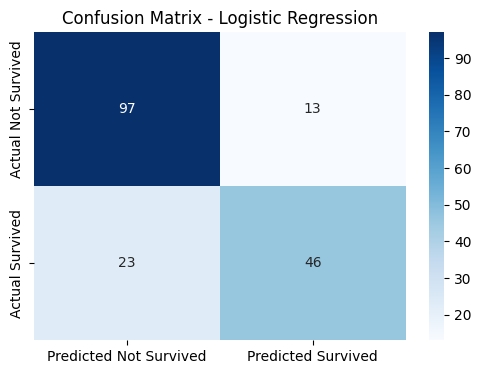

<Figure size 640x480 with 0 Axes>

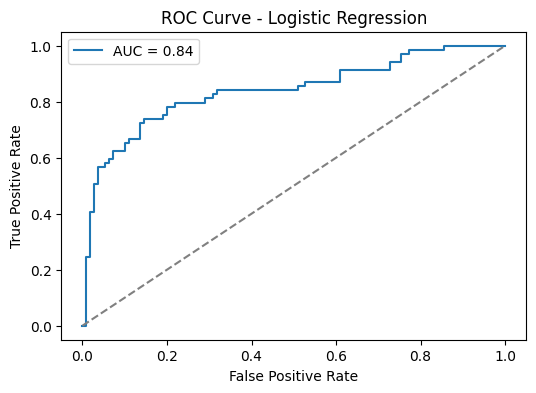

<Figure size 640x480 with 0 Axes>

In [18]:
# -----------------------------
# 6a. Logistic Regression Evaluation
# -----------------------------
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Not Survived", "Predicted Survived"],
            yticklabels=["Actual Not Survived", "Actual Survived"])
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("images/confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC Curve
y_pred_proba_lr = log_reg.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"AUC = {roc_auc_lr:.2f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("images/roc_curve_logreg.png", dpi=300, bbox_inches="tight")
plt.show()


# 📌 Cell 7: Stronger Model (XGBoost + Tuning)

In [19]:
# -----------------------------
# 7. Stronger Model: XGBoost
# -----------------------------
xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"))
])

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.01, 0.1]
}

grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring="f1", verbose=1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred_xgb = best_model.predict(X_test)
print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
XGBoost Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



# 📌Cell 7a: XGBoost Evaluation (Plots + Save)  

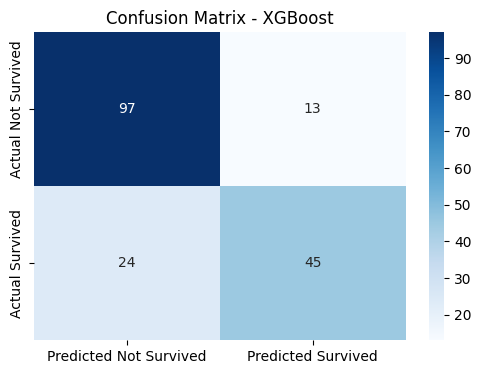

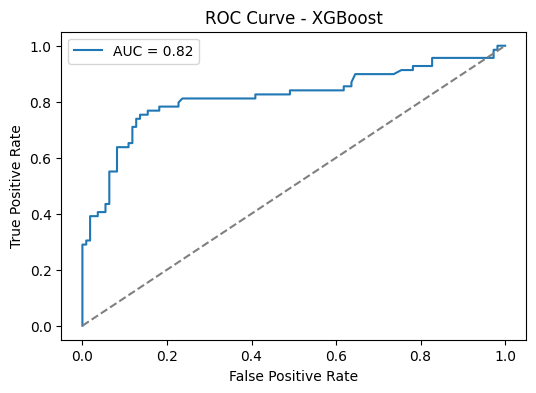

In [23]:
# -----------------------------
# 7a. XGBoost Evaluation
# -----------------------------
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Not Survived", "Predicted Survived"],
            yticklabels=["Actual Not Survived", "Actual Survived"])
plt.title("Confusion Matrix - XGBoost")
plt.savefig("images/confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC Curve
y_pred_proba_xgb = best_model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6,4))
plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {roc_auc_xgb:.2f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.savefig("images/roc_curve_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

# 📌 Cell 8: Evaluation

XGBoost Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



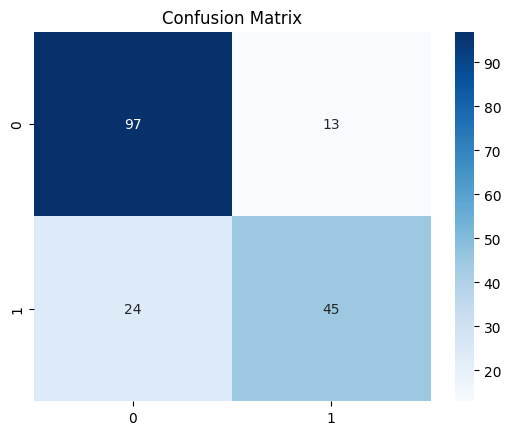

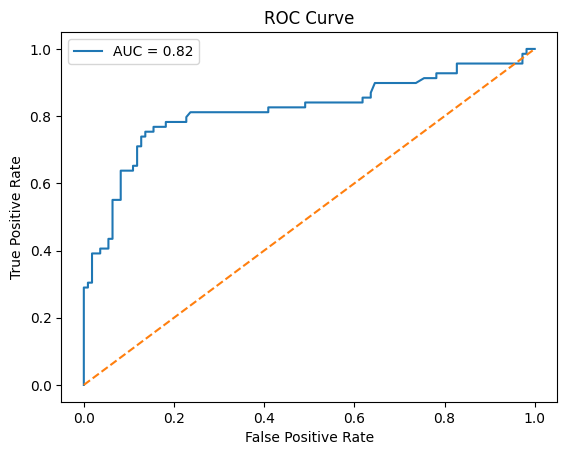

<Figure size 640x480 with 0 Axes>

In [24]:
# -----------------------------
# 8. Evaluation
# -----------------------------
y_pred_xgb = best_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
plt.savefig("images/confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.savefig("images/roc_curve_xgb.png", dpi=300, bbox_inches="tight")


# ROC curve
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
plt.savefig("images/confusion_matrix_xgb.png", dpi=300, bbox_inches="tight")
plt.savefig("images/roc_curve_xgb.png", dpi=300, bbox_inches="tight")



# 📌 Cell 9: Save Pipeline

In [25]:
# -----------------------------
# 9. Save Pipelines
# -----------------------------
import joblib

# Save XGBoost best model
joblib.dump(best_model, "titanic_xgb_pipeline.pkl")

# Save Logistic Regression pipeline
joblib.dump(log_reg, "titanic_logreg_pipeline.pkl")


['titanic_logreg_pipeline.pkl']

In [19]:
import joblib

# Reload Logistic Regression
logreg_loaded = joblib.load("titanic_logreg_pipeline.pkl")
print("LogReg predictions:", logreg_loaded.predict(X_test[:5]))

# Reload XGBoost
xgb_loaded = joblib.load("titanic_xgb_pipeline.pkl")
print("XGBoost predictions:", xgb_loaded.predict(X_test[:5]))


LogReg predictions: [0 0 0 0 1]
XGBoost predictions: [0 0 0 0 1]
